In [1]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [2]:
!pip install -q ultralytics roboflow gradio opencv-contrib-python pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.6/324.6 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 7.8 MB/s eta 0:00:00


In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import json
import math

from PIL import Image

from ultralytics import YOLO, SAM

print("Libraries loaded")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Libraries loaded


In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="GF95E7toWhhgp5R6wtAN")
project = rf.workspace("onion-grading-nx").project("veg1-hcqsf-2")
version = project.version(4)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to veg1-hcqsf/2-4 in yolov8:: 100%|██████████| 3404/3404 [00:00<00:00, 7190.55it/s]


In [5]:
DATA_YAML = "/content/veg1-hcqsf/2-4/data.yaml"

print(open(DATA_YAML).read())

names:
- double_split
- onion
- rotten
- sprout
nc: 4
roboflow:
  license: CC BY 4.0
  project: veg1-hcqsf
  url: https://universe.roboflow.com/onion-grading-nx/veg1-hcqsf/dataset/4
  version: 4
  workspace: onion-grading-nx
test: ../test/images
train: ../train/images
val: ../valid/images



In [9]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/onion_project",
    name="onion_quality",
    patience=10
)

Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/veg1-hcqsf/2-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=onion_quality, nbs=64, nms=None, opset=None, optimize=F

In [11]:
YOLO_MODEL_PATH = "/content/onion_project/onion_quality/weights/best.pt"

detector = YOLO(YOLO_MODEL_PATH)

print(detector.names)

{0: 'double_split', 1: 'onion', 2: 'rotten', 3: 'sprout'}


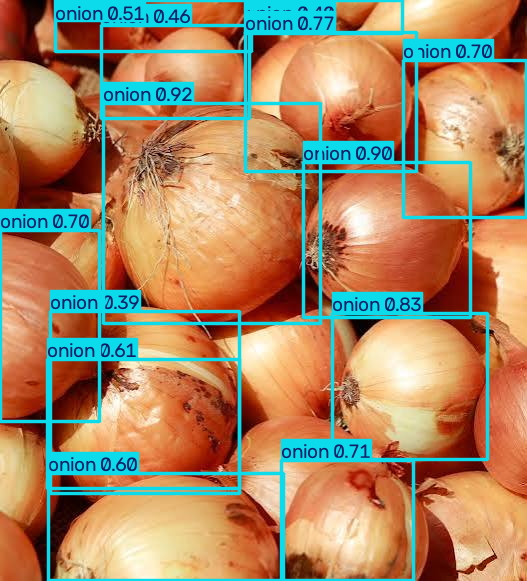

In [14]:
TEST_IMAGE = "/content/onion.jpeg"

results = detector.predict(
    source=TEST_IMAGE,
    conf=0.25,
    verbose=False
)

results[0].show()

In [15]:
result = results[0]

onion_boxes = []

for box in result.boxes:

    class_id = int(box.cls[0])

    class_name = detector.names[class_id]

    if class_name == "onion":

        xyxy = box.xyxy[0].cpu().numpy().tolist()

        onion_boxes.append(xyxy)

print("Number of onions:", len(onion_boxes))
print("Boxes:", onion_boxes)

Number of onions: 13
Boxes: [[103.2439956665039, 103.45978546142578, 320.4139099121094, 323.3563537597656], [303.0389404296875, 162.8018341064453, 470.9580993652344, 317.1443786621094], [332.1283874511719, 313.7252502441406, 487.5478210449219, 459.27252197265625], [245.7604217529297, 32.836490631103516, 416.4794616699219, 171.8149871826172], [281.1292419433594, 460.56976318359375, 413.45263671875, 580.9743041992188], [0.0, 230.22140502929688, 99.03843688964844, 421.01348876953125], [403.26104736328125, 60.0456657409668, 526.6038818359375, 217.465576171875], [47.99277114868164, 359.7354736328125, 239.30738830566406, 488.5509948730469], [48.22953414916992, 473.7369384765625, 283.8143615722656, 580.8696899414062], [55.99209213256836, 0.05490979924798012, 251.47732543945312, 51.4038200378418], [101.24677276611328, 25.694499969482422, 249.65103149414062, 118.0950927734375], [245.333740234375, 0.04341946542263031, 402.2521057128906, 33.091156005859375], [50.296939849853516, 311.4161376953125

In [16]:
sam = SAM("sam2.1_b.pt")

print("SAM2 loaded")

SAM2 loaded


In [19]:
sam_results = sam(
    TEST_IMAGE,
    bboxes=onion_boxes,
    verbose=False
)

sam_result = sam_results[0]

print(sam_result.masks)

ultralytics.engine.results.Masks object with attributes:

data: tensor([[[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]],

        [[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]],

        [[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
     

In [20]:
if sam_result.masks is not None:

    masks = sam_result.masks.data.cpu().numpy()

    print("Number of masks:", len(masks))
    print("Mask shape:", masks.shape)

else:

    print("No masks generated")

Number of masks: 13
Mask shape: (13, 581, 527)


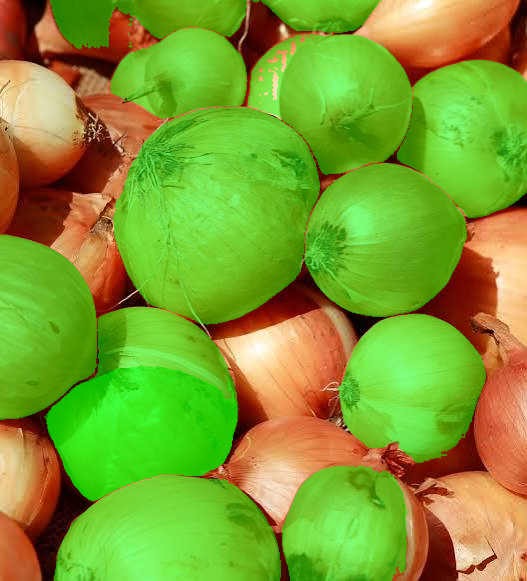

In [21]:
image = cv2.imread(TEST_IMAGE)

overlay = image.copy()

for mask in masks:

    mask_uint8 = (mask > 0.5).astype(np.uint8)

    overlay[mask_uint8 == 1] = (
        0.5 * overlay[mask_uint8 == 1]
        + 0.5 * np.array([0, 255, 0])
    ).astype(np.uint8)

output = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

display(Image.fromarray(output))

In [89]:
import cv2
import numpy as np

dictionary = cv2.aruco.getPredefinedDictionary(
    cv2.aruco.DICT_6X6_250
)

marker_id = 23

# Generate marker code
marker = cv2.aruco.generateImageMarker(
    dictionary,
    marker_id,
    500
)

# Add a white border around the marker
border = 50

marker_with_border = cv2.copyMakeBorder(
    marker,
    border,
    border,
    border,
    border,
    cv2.BORDER_CONSTANT,
    value=255
)

cv2.imwrite(
    "/content/onion_reference_marker.png",
    marker_with_border
)

print("Marker created:", marker_with_border.shape)

Marker created: (600, 600)


In [90]:
from google.colab import files

files.download("/content/onion_reference_marker.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [135]:
image = cv2.imread("/content/onion_reference_marker.png")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

dictionary = cv2.aruco.getPredefinedDictionary(
    cv2.aruco.DICT_6X6_250
)

parameters = cv2.aruco.DetectorParameters()

detector = cv2.aruco.ArucoDetector(
    dictionary,
    parameters
)

corners, ids, rejected = detector.detectMarkers(gray)

print("Detected IDs:", ids)
print("Rejected:", len(rejected))

Detected IDs: [23]
Rejected: 2


In [136]:
if ids is not None:

    for i, marker_id in enumerate(ids.flatten()):

        if marker_id == 23:

            points = corners[i][0]

            lengths = [
                np.linalg.norm(points[0] - points[1]),
                np.linalg.norm(points[1] - points[2]),
                np.linalg.norm(points[2] - points[3]),
                np.linalg.norm(points[3] - points[0])
            ]

            marker_pixels = np.mean(lengths)

            print("Marker pixel size:", marker_pixels)

Marker pixel size: 499.0


In [137]:
def detect_reference_marker(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    dictionary = cv2.aruco.getPredefinedDictionary(
        cv2.aruco.DICT_6X6_250
    )

    parameters = cv2.aruco.DetectorParameters()

    aruco_detector = cv2.aruco.ArucoDetector(
        dictionary,
        parameters
    )

    corners, ids, _ = aruco_detector.detectMarkers(gray)

    if ids is None:
        return None

    for i, marker_id in enumerate(ids.flatten()):
        if marker_id == 23:
            points = corners[i][0]

            lengths = [
                np.linalg.norm(points[0] - points[1]),
                np.linalg.norm(points[1] - points[2]),
                np.linalg.norm(points[2] - points[3]),
                np.linalg.norm(points[3] - points[0])
            ]

            return float(np.mean(lengths))

    return None

In [138]:
CALIBRATION_IMAGE = "/content/onion_reference_marker.png"

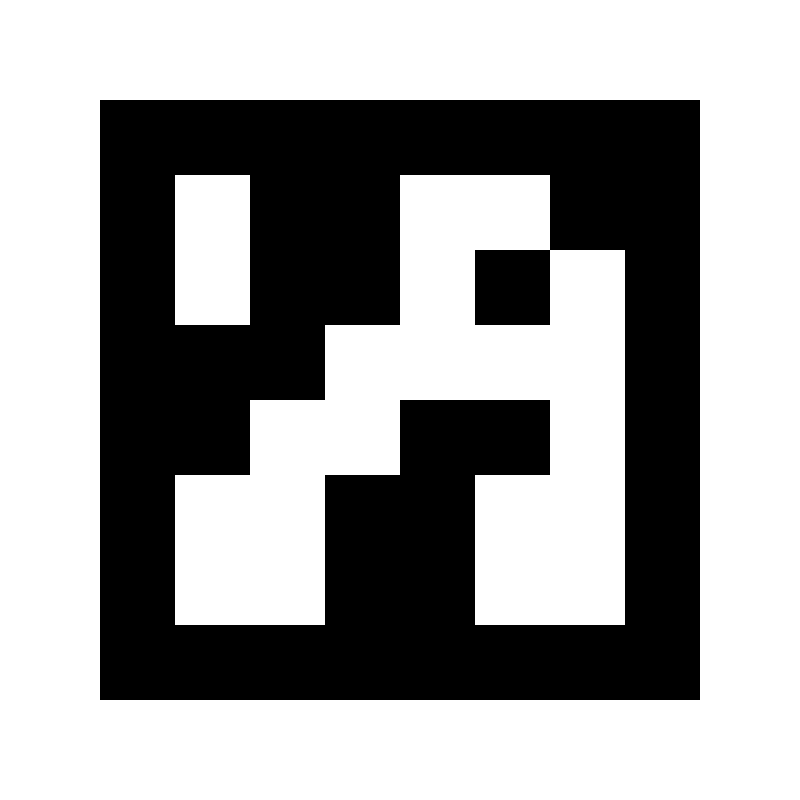

In [139]:
import cv2
import numpy as np
from PIL import Image
from IPython.display import display

dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)

marker = cv2.aruco.generateImageMarker(
    dictionary,
    23,
    600,
    borderBits=1
)

marker = cv2.copyMakeBorder(
    marker,
    100, 100, 100, 100,
    cv2.BORDER_CONSTANT,
    value=255
)

display(Image.fromarray(marker))

In [140]:
gray = marker.copy()

parameters = cv2.aruco.DetectorParameters()

aruco_detector = cv2.aruco.ArucoDetector(
    dictionary,
    parameters
)

corners, ids, rejected = aruco_detector.detectMarkers(gray)

print("Detected IDs:", ids)
print("Rejected markers:", len(rejected))

Detected IDs: [23]
Rejected markers: 2


In [141]:
image = cv2.imread(CALIBRATION_IMAGE)

marker_pixels = detect_reference_marker(image)

print("Marker pixel size:", marker_pixels)

Marker pixel size: 499.0


In [142]:
REFERENCE_SIZE_MM = 50

mm_per_pixel = REFERENCE_SIZE_MM / marker_pixels

print("mm per pixel:", mm_per_pixel)

mm per pixel: 0.10020040080160321


In [143]:
def measure_mask(mask):

    mask_uint8 = (
        (mask > 0.5).astype(np.uint8) * 255
    )

    contours, _ = cv2.findContours(
        mask_uint8,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return None

    contour = max(
        contours,
        key=cv2.contourArea
    )

    area = cv2.contourArea(contour)

    x, y, w, h = cv2.boundingRect(contour)

    return {
        "area_pixels": area,
        "width_pixels": w,
        "height_pixels": h,
        "diameter_pixels": max(w, h)
    }

In [144]:
onion_measurements = []

for i, mask in enumerate(masks):

    measurement = measure_mask(mask)

    if measurement is None:
        continue

    diameter_mm = (
        measurement["diameter_pixels"]
        * mm_per_pixel
    )

    onion_measurements.append({

        "onion_id": i + 1,

        "diameter_pixels":
            measurement["diameter_pixels"],

        "diameter_mm":
            round(diameter_mm, 2),

        "area_pixels":
            round(
                measurement["area_pixels"],
                2
            )
    })

pd.DataFrame(onion_measurements)

,onion_id,diameter_pixels,diameter_mm,area_pixels
0,1,218,21.84,34120.0
1,2,163,16.33,18863.0
2,3,149,14.93,15974.5
3,4,165,16.53,16213.5
4,5,125,12.53,12381.0
5,6,185,18.54,14055.5
6,7,158,15.83,15326.0
7,8,190,19.04,18000.5
8,9,227,22.75,19008.0
9,10,197,19.74,5877.5


In [145]:
def local_market_size(diameter_mm):

    if diameter_mm > 60:
        return "Extra Large"

    elif diameter_mm >= 40:
        return "Medium"

    elif diameter_mm >= 20:
        return "Small"

    else:
        return "Below 20 mm"

In [146]:
for item in onion_measurements:

    item["size_category"] = local_market_size(
        item["diameter_mm"]
    )

pd.DataFrame(onion_measurements)

,onion_id,diameter_pixels,diameter_mm,area_pixels,size_category
0,1,218,21.84,34120.0,Small
1,2,163,16.33,18863.0,Below 20 mm
2,3,149,14.93,15974.5,Below 20 mm
3,4,165,16.53,16213.5,Below 20 mm
4,5,125,12.53,12381.0,Below 20 mm
5,6,185,18.54,14055.5,Below 20 mm
6,7,158,15.83,15326.0,Below 20 mm
7,8,190,19.04,18000.5,Below 20 mm
8,9,227,22.75,19008.0,Small
9,10,197,19.74,5877.5,Below 20 mm


In [147]:
defect_detections = []

for box in result.boxes:

    class_id = int(box.cls[0])

    class_name = model.names[class_id]

    confidence = float(box.conf[0])

    print(
        "Class:", class_name,
        "| Confidence:", confidence
    )

    if class_name != "onion":

        xyxy = box.xyxy[0].cpu().numpy().tolist()

        defect_detections.append({
            "class": class_name,
            "confidence": confidence,
            "box": xyxy
        })

print("\nDefect detections:")
print(defect_detections)

Class: onion | Confidence: 0.9150828123092651
Class: onion | Confidence: 0.9018959403038025
Class: onion | Confidence: 0.8282999992370605
Class: onion | Confidence: 0.7734664678573608
Class: onion | Confidence: 0.709211528301239
Class: onion | Confidence: 0.7040773630142212
Class: onion | Confidence: 0.7004303932189941
Class: onion | Confidence: 0.6091629862785339
Class: onion | Confidence: 0.6018036007881165
Class: onion | Confidence: 0.5098960399627686
Class: onion | Confidence: 0.46246758103370667
Class: onion | Confidence: 0.39666441082954407
Class: onion | Confidence: 0.3923130929470062

Defect detections:
[]


In [148]:
def box_center(box):

    x1, y1, x2, y2 = box

    return (
        (x1 + x2) / 2,
        (y1 + y2) / 2
    )

In [149]:
def point_inside_mask(x, y, mask):

    h, w = mask.shape

    x = int(round(x))
    y = int(round(y))

    if x < 0 or x >= w:
        return False

    if y < 0 or y >= h:
        return False

    return bool(mask[y, x])

In [150]:
onion_records = []

for i, item in enumerate(onion_measurements):

    onion_records.append({

        "onion_id":
            item["onion_id"],

        "diameter_mm":
            item["diameter_mm"],

        "size_category":
            item["size_category"],

        "rotten":
            False,

        "sprout":
            False,

        "double_split":
            False
    })

In [151]:
for i, mask in enumerate(masks):

    for defect in defect_detections:

        cx, cy = box_center(
            defect["box"]
        )

        if point_inside_mask(
            cx,
            cy,
            mask
        ):

            class_name = defect["class"]

            if class_name == "rotten":

                onion_records[i]["rotten"] = True

            elif class_name == "sprout":

                onion_records[i]["sprout"] = True

            elif class_name == "double_split":

                onion_records[i]["double_split"] = True

In [152]:
pd.DataFrame(onion_records)

,onion_id,diameter_mm,size_category,rotten,sprout,double_split
0,1,21.84,Small,False,False,False
1,2,16.33,Below 20 mm,False,False,False
2,3,14.93,Below 20 mm,False,False,False
3,4,16.53,Below 20 mm,False,False,False
4,5,12.53,Below 20 mm,False,False,False
5,6,18.54,Below 20 mm,False,False,False
6,7,15.83,Below 20 mm,False,False,False
7,8,19.04,Below 20 mm,False,False,False
8,9,22.75,Small,False,False,False
9,10,19.74,Below 20 mm,False,False,False


In [153]:
def determine_condition(record):

    defects = []

    if record["rotten"]:
        defects.append("Visible rot")

    if record["sprout"]:
        defects.append("Sprouting")

    if record["double_split"]:
        defects.append("Double/split")

    if len(defects) == 0:

        return "No detected visible defect", []

    return "Visible defect detected", defects

In [154]:
for record in onion_records:

    condition, defects = determine_condition(
        record
    )

    record["condition"] = condition
    record["defects"] = defects

pd.DataFrame(onion_records)

,onion_id,diameter_mm,size_category,rotten,sprout,double_split,condition,defects
0,1,21.84,Small,False,False,False,No detected visible defect,[]
1,2,16.33,Below 20 mm,False,False,False,No detected visible defect,[]
2,3,14.93,Below 20 mm,False,False,False,No detected visible defect,[]
3,4,16.53,Below 20 mm,False,False,False,No detected visible defect,[]
4,5,12.53,Below 20 mm,False,False,False,No detected visible defect,[]
5,6,18.54,Below 20 mm,False,False,False,No detected visible defect,[]
6,7,15.83,Below 20 mm,False,False,False,No detected visible defect,[]
7,8,19.04,Below 20 mm,False,False,False,No detected visible defect,[]
8,9,22.75,Small,False,False,False,No detected visible defect,[]
9,10,19.74,Below 20 mm,False,False,False,No detected visible defect,[]


In [155]:
STANDARDS = {

    "local_market": {

        "name":
            "NHB Local Market Size Categories",

        "type":
            "size_classification"

    },

    "nhb_nasik": {

        "name":
            "NHB Export - Nasik / Saurashtra / Bellary / Poona",

        "minimum_diameter_mm":
            20,

        "decay_max_percent":
            2,

        "defective_weight_limit_percent":
            10
    },

    "nhb_bangalore": {

        "name":
            "NHB Export - Bangalore",

        "minimum_diameter_mm":
            15,

        "decay_max_percent":
            2
    },

    "nhb_krishnapuram": {

        "name":
            "NHB Export - Krishnapuram",

        "minimum_diameter_mm":
            15,

        "decay_max_percent":
            2
    }
}

In [156]:
def calculate_lot_statistics(records):

    total = len(records)

    if total == 0:
        return {}

    rotten = sum(
        r["rotten"]
        for r in records
    )

    sprout = sum(
        r["sprout"]
        for r in records
    )

    double_split = sum(
        r["double_split"]
        for r in records
    )

    defective = sum(
        bool(r["defects"])
        for r in records
    )

    return {

        "total_onions":
            total,

        "rotten":
            rotten,

        "sprouted":
            sprout,

        "double_split":
            double_split,

        "defective_onions":
            defective,

        "defective_count_percent":
            round(
                defective / total * 100,
                2
            ),

        "rotten_count_percent":
            round(
                rotten / total * 100,
                2
            )
    }

In [157]:
lot_stats = calculate_lot_statistics(
    onion_records
)

lot_stats

{'total_onions': 13,
 'rotten': 0,
 'sprouted': 0,
 'double_split': 0,
 'defective_onions': 0,
 'defective_count_percent': 0.0,
 'rotten_count_percent': 0.0}

In [158]:
def apply_rules(records, standard_id):

    standard = STANDARDS[standard_id]

    stats = calculate_lot_statistics(records)

    results = []

    for record in records:

        diameter = record["diameter_mm"]

        if "minimum_diameter_mm" in standard:

            if diameter < standard["minimum_diameter_mm"]:

                size_status = "Below minimum"

            else:

                size_status = "Meets minimum size"

        else:

            size_status = record["size_category"]

        results.append({

            "onion_id":
                record["onion_id"],

            "diameter_mm":
                record["diameter_mm"],

            "size_status":
                size_status,

            "condition":
                record["condition"],

            "defects":
                record["defects"]
        })

    return results, stats

In [159]:
def verification_status(records):

    uncertain = []

    for record in records:

        if record["diameter_mm"] <= 0:

            uncertain.append(
                record["onion_id"]
            )

    if uncertain:

        return "Manual verification required"

    return "AI assessment completed; verify before regulatory decision"

In [160]:
def generate_report(
    records,
    standard_id
):

    standard = STANDARDS[standard_id]

    graded, stats = apply_rules(
        records,
        standard_id
    )

    verification = verification_status(
        records
    )

    report = f"""
# Onion Quality Assessment

## Selected Standard

**{standard["name"]}**

## Lot Summary

| Parameter | Result |
|---|---:|
| Total onions detected | {stats["total_onions"]} |
| Visible rotten onions | {stats["rotten"]} |
| Sprouted onions | {stats["sprouted"]} |
| Double/split onions | {stats["double_split"]} |
| Onions with detected visible defects | {stats["defective_onions"]} |
| Defective count indicator | {stats["defective_count_percent"]}% |

## Onion Measurements

"""

    for onion in graded:

        report += f"""

### Onion {onion["onion_id"]}

- Diameter: **{onion["diameter_mm"]} mm**
- Size result: **{onion["size_status"]}**
- Condition: **{onion["condition"]}**
- Defects: **{", ".join(onion["defects"]) if onion["defects"] else "None detected"}**
"""

    report += f"""

## Verification

**{verification}**

## Important

The AI performs visual detection and image-based size estimation.
Count-based defect percentages are visual indicators and must not be interpreted as weight-based regulatory percentages.
Hidden/internal defects cannot be reliably determined from an ordinary RGB image.
"""

    return report

In [161]:
report = generate_report(
    onion_records,
    "local_market"
)

print(report)


# Onion Quality Assessment

## Selected Standard

**NHB Local Market Size Categories**

## Lot Summary

| Parameter | Result |
|---|---:|
| Total onions detected | 13 |
| Visible rotten onions | 0 |
| Sprouted onions | 0 |
| Double/split onions | 0 |
| Onions with detected visible defects | 0 |
| Defective count indicator | 0.0% |

## Onion Measurements



### Onion 1

- Diameter: **21.84 mm**
- Size result: **Small**
- Condition: **No detected visible defect**
- Defects: **None detected**


### Onion 2

- Diameter: **16.33 mm**
- Size result: **Below 20 mm**
- Condition: **No detected visible defect**
- Defects: **None detected**


### Onion 3

- Diameter: **14.93 mm**
- Size result: **Below 20 mm**
- Condition: **No detected visible defect**
- Defects: **None detected**


### Onion 4

- Diameter: **16.53 mm**
- Size result: **Below 20 mm**
- Condition: **No detected visible defect**
- Defects: **None detected**


### Onion 5

- Diameter: **12.53 mm**
- Size result: **Below 20 mm**
-

In [178]:
def process_image(
    image_path,
    standard_id="local_market"
):

    image = cv2.imread(image_path)

    if image is None:
        return None, None, "Could not read image."

    # -----------------------------
    # 1. YOLO DETECTION
    # -----------------------------

    detections = detector.predict(
        source=image_path,
        conf=0.25,
        verbose=False
    )[0]

    onion_boxes = []

    for box in detections.boxes:

        class_id = int(box.cls[0])
        class_name = detector.names[class_id]

        if class_name == "onion":

            onion_boxes.append(
                box.xyxy[0].cpu().numpy().tolist()
            )

    if len(onion_boxes) == 0:
        return None, None, "No onions detected."

    # -----------------------------
    # 2. ARUCO CALIBRATION
    # -----------------------------

    marker_pixels = detect_reference_marker(image)

    if marker_pixels is None:
        return None, None, (
            "Reference marker not detected. "
            "Place the 50 mm reference marker in the image."
        )

    mm_per_pixel = (
        REFERENCE_SIZE_MM / marker_pixels
    )

    # -----------------------------
    # 3. SAM2 SEGMENTATION
    # -----------------------------

    sam_results = sam(
        image_path,
        bboxes=onion_boxes,
        verbose=False
    )

    sam_result = sam_results[0]

    if sam_result.masks is None:
        return None, None, (
            "Could not generate onion masks."
        )

    masks = (
        sam_result.masks.data
        .cpu()
        .numpy()
    )

    # -----------------------------
    # 4. ONION MEASUREMENTS
    # -----------------------------

    records = []

    for i, mask in enumerate(masks):

        measurement = measure_mask(mask)

        if measurement is None:
            continue

        diameter_mm = (
            measurement["diameter_pixels"]
            * mm_per_pixel
        )

        records.append({

            "onion_id":
                len(records) + 1,

            "diameter_mm":
                round(diameter_mm, 2),

            "size_category":
                local_market_size(
                    diameter_mm
                ),

            "rotten":
                False,

            "sprout":
                False,

            "double_split":
                False
        })

    # -----------------------------
    # 5. DEFECT ASSOCIATION
    # -----------------------------

    valid_mask_index = 0

    for mask in masks:

        measurement = measure_mask(mask)

        if measurement is None:
            continue

        if valid_mask_index >= len(records):
            continue

        for box in detections.boxes:

            class_id = int(box.cls[0])
            class_name = detector.names[class_id]

            if class_name == "onion":
                continue

            defect_box = (
                box.xyxy[0]
                .cpu()
                .numpy()
                .tolist()
            )

            cx, cy = box_center(defect_box)

            if point_inside_mask(
                cx,
                cy,
                mask
            ):

                if class_name == "rotten":

                    records[
                        valid_mask_index
                    ]["rotten"] = True

                elif class_name == "sprout":

                    records[
                        valid_mask_index
                    ]["sprout"] = True

                elif class_name == "double_split":

                    records[
                        valid_mask_index
                    ]["double_split"] = True

        valid_mask_index += 1

    # -----------------------------
    # 6. CONDITION
    # -----------------------------

    for record in records:

        condition, defects = (
            determine_condition(record)
        )

        record["condition"] = condition
        record["defects"] = defects

    # -----------------------------
    # 7. LOT STATISTICS
    # -----------------------------

    lot_statistics = calculate_lot_statistics(
        records
    )

    # -----------------------------
    # 8. VERIFICATION
    # -----------------------------

    verification = verification_status(
        records
    )

    # -----------------------------
    # 9. MARKDOWN REPORT
    # -----------------------------

    report = generate_report(
        records,
        standard_id
    )

    # -----------------------------
    # 10. STRUCTURED API OUTPUT
    # -----------------------------

    result_data = {

        "success": True,

        "standard": standard_id,

        "calibration": {

            "reference_size_mm":
                REFERENCE_SIZE_MM,

            "marker_pixels":
                round(marker_pixels, 2),

            "mm_per_pixel":
                round(mm_per_pixel, 4)
        },

        "lot_summary": lot_statistics,

        "onions": records,

        "verification": verification,

        "limitations": [
            "Assessment is based on visible image evidence.",
            "Count-based defect percentages are visual indicators.",
            "They must not be interpreted as weight-based regulatory percentages.",
            "Hidden or internal defects cannot be reliably determined from ordinary RGB images."
        ]
    }

    # -----------------------------
    # 11. ANNOTATED IMAGE
    # -----------------------------

    annotated = detections.plot()

    annotated = Image.fromarray(
        annotated
    )

    return annotated, result_data, report

In [179]:
annotated, result_data, report = process_image(
    TEST_IMAGE,
    standard_id="local_market"
)

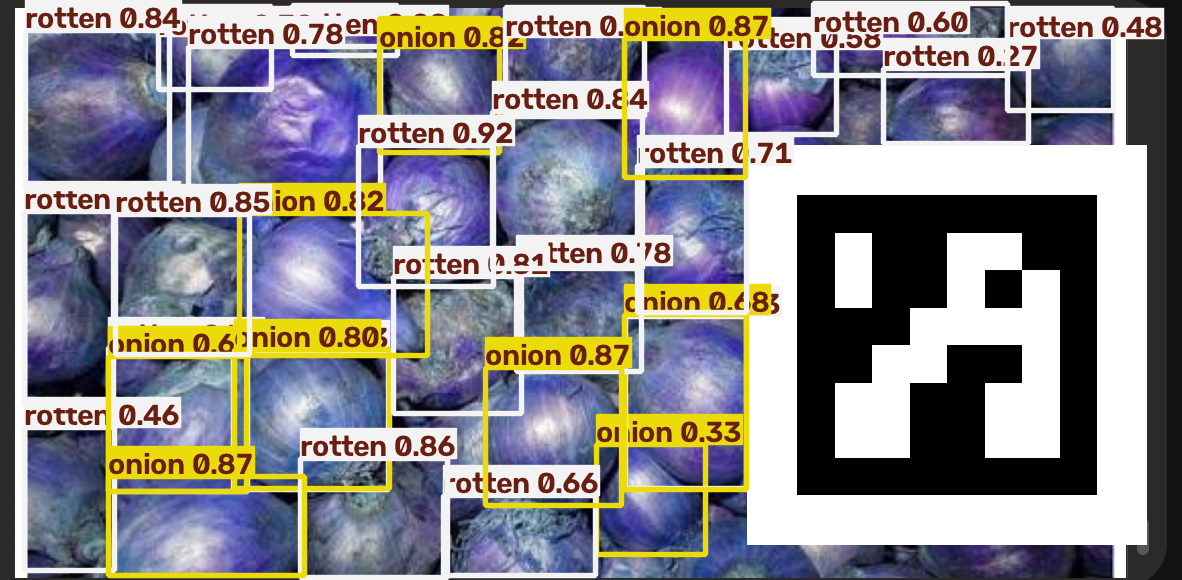

STRUCTURED DATA:
{'success': True, 'standard': 'local_market', 'calibration': {'reference_size_mm': 50, 'marker_pixels': 299.0, 'mm_per_pixel': 0.1672}, 'lot_summary': {'total_onions': 9, 'rotten': 3, 'sprouted': 0, 'double_split': 0, 'defective_onions': 3, 'defective_count_percent': 33.33, 'rotten_count_percent': 33.33}, 'onions': [{'onion_id': 1, 'diameter_mm': 23.91, 'size_category': 'Small', 'rotten': False, 'sprout': False, 'double_split': False, 'condition': 'No detected visible defect', 'defects': []}, {'onion_id': 2, 'diameter_mm': 24.41, 'size_category': 'Small', 'rotten': False, 'sprout': False, 'double_split': False, 'condition': 'No detected visible defect', 'defects': []}, {'onion_id': 3, 'diameter_mm': 33.78, 'size_category': 'Small', 'rotten': False, 'sprout': False, 'double_split': False, 'condition': 'No detected visible defect', 'defects': []}, {'onion_id': 4, 'diameter_mm': 30.43, 'size_category': 'Small', 'rotten': False, 'sprout': False, 'double_split': False, 'con

In [180]:
display(annotated)

print("STRUCTURED DATA:")
print(result_data)

print("\nREPORT:")
print(report)

In [181]:
from ultralytics import YOLO

YOLO_MODEL_PATH = "/content/onion_project/onion_quality/weights/best.pt"

detector = YOLO(YOLO_MODEL_PATH)

print(detector.names)

{0: 'double_split', 1: 'onion', 2: 'rotten', 3: 'sprout'}


In [182]:
TEST_IMAGE = "/content/onion_test_with_aruco_marker.png"

In [186]:
image = cv2.imread(TEST_IMAGE)

marker_pixels = detect_reference_marker(image)

print("Marker pixel size:", marker_pixels)

Marker pixel size: 299.0


In [187]:
REFERENCE_SIZE_MM = 50

mm_per_pixel = REFERENCE_SIZE_MM / marker_pixels

print("mm per pixel:", mm_per_pixel)

mm per pixel: 0.16722408026755853


In [188]:
import json

print(
    json.dumps(
        result_data,
        indent=4
    )
)

{
    "success": true,
    "standard": "local_market",
    "calibration": {
        "reference_size_mm": 50,
        "marker_pixels": 299.0,
        "mm_per_pixel": 0.1672
    },
    "lot_summary": {
        "total_onions": 9,
        "rotten": 3,
        "sprouted": 0,
        "double_split": 0,
        "defective_onions": 3,
        "defective_count_percent": 33.33,
        "rotten_count_percent": 33.33
    },
    "onions": [
        {
            "onion_id": 1,
            "diameter_mm": 23.91,
            "size_category": "Small",
            "rotten": false,
            "sprout": false,
            "double_split": false,
            "condition": "No detected visible defect",
            "defects": []
        },
        {
            "onion_id": 2,
            "diameter_mm": 24.41,
            "size_category": "Small",
            "rotten": false,
            "sprout": false,
            "double_split": false,
            "condition": "No detected visible defect",
            "defe

In [191]:
from fastapi import FastAPI, UploadFile, File
import tempfile
import os

app = FastAPI()

@app.get("/")
def home():
    return {"message": "Onion Quality ML API is running"}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):

    suffix = os.path.splitext(file.filename)[1]

    with tempfile.NamedTemporaryFile(
        delete=False,
        suffix=suffix
    ) as temp:
        temp.write(await file.read())
        image_path = temp.name

    try:
        annotated, result_data, report = process_image(
            image_path,
            standard_id="local_market"
        )

        return result_data

    finally:
        os.remove(image_path)

In [192]:
!pip install -q fastapi uvicorn python-multipart nest-asyncio pyngrok

In [193]:
print(detector)
print(sam)
print(process_image)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

In [194]:
TEST_IMAGE = "/content/onion_test_with_aruco_marker.png"

annotated, result_data, report = process_image(
    TEST_IMAGE,
    standard_id="local_market"
)

print(result_data)

{'success': True, 'standard': 'local_market', 'calibration': {'reference_size_mm': 50, 'marker_pixels': 299.0, 'mm_per_pixel': 0.1672}, 'lot_summary': {'total_onions': 9, 'rotten': 3, 'sprouted': 0, 'double_split': 0, 'defective_onions': 3, 'defective_count_percent': 33.33, 'rotten_count_percent': 33.33}, 'onions': [{'onion_id': 1, 'diameter_mm': 23.91, 'size_category': 'Small', 'rotten': False, 'sprout': False, 'double_split': False, 'condition': 'No detected visible defect', 'defects': []}, {'onion_id': 2, 'diameter_mm': 24.41, 'size_category': 'Small', 'rotten': False, 'sprout': False, 'double_split': False, 'condition': 'No detected visible defect', 'defects': []}, {'onion_id': 3, 'diameter_mm': 33.78, 'size_category': 'Small', 'rotten': False, 'sprout': False, 'double_split': False, 'condition': 'No detected visible defect', 'defects': []}, {'onion_id': 4, 'diameter_mm': 30.43, 'size_category': 'Small', 'rotten': False, 'sprout': False, 'double_split': False, 'condition': 'No dete

In [195]:
from fastapi import FastAPI, UploadFile, File
import tempfile
import os

app = FastAPI(
    title="Onion Quality Grading API",
    description="AI-based onion quality assessment using YOLO11, SAM2 and OpenCV",
    version="1.0.0"
)

@app.get("/")
def home():
    return {
        "message": "Onion Quality Grading API is running",
        "status": "ok"
    }

In [200]:
@app.post("/predict")
async def predict(file: UploadFile = File(...)):

    suffix = os.path.splitext(file.filename)[1]

    with tempfile.NamedTemporaryFile(
        delete=False,
        suffix=suffix
    ) as temp:

        temp.write(await file.read())
        image_path = temp.name

    try:

        annotated, result_data, report = process_image(
            image_path,
            standard_id="local_market"
        )

        return result_data

    finally:

        if os.path.exists(image_path):
            os.remove(image_path)

In [201]:
for route in app.routes:
    print(route.path, route.methods)

/openapi.json {'HEAD', 'GET'}
/docs {'HEAD', 'GET'}
/docs/oauth2-redirect {'HEAD', 'GET'}
/redoc {'HEAD', 'GET'}
/ {'GET'}
/predict {'POST'}
/predict {'POST'}


In [203]:
import nest_asyncio
import uvicorn
import threading

nest_asyncio.apply()

def run_api():
    uvicorn.run(
        app,
        host="0.0.0.0",
        port=8000
    )

api_thread = threading.Thread(
    target=run_api,
    daemon=True
)

api_thread.start()

INFO:     Started server process [680]
INFO:     Waiting for application startup.


In [204]:
import requests

response = requests.get("http://127.0.0.1:8000/")
print(response.status_code)
print(response.json())

INFO:     127.0.0.1:34916 - "GET / HTTP/1.1" 200 OK
200
{'message': 'Onion Quality Grading API is running', 'status': 'ok'}


In [205]:
import requests

TEST_IMAGE = "/content/onion_test_with_aruco_marker.png"

with open(TEST_IMAGE, "rb") as image_file:
    response = requests.post(
        "http://127.0.0.1:8000/predict",
        files={
            "file": (
                "onion_test.png",
                image_file,
                "image/png"
            )
        }
    )

print("Status:", response.status_code)
print(response.json())

INFO:     127.0.0.1:46296 - "POST /predict HTTP/1.1" 200 OK
Status: 200
{'success': True, 'standard': 'local_market', 'calibration': {'reference_size_mm': 50, 'marker_pixels': 299.0, 'mm_per_pixel': 0.1672}, 'lot_summary': {'total_onions': 9, 'rotten': 3, 'sprouted': 0, 'double_split': 0, 'defective_onions': 3, 'defective_count_percent': 33.33, 'rotten_count_percent': 33.33}, 'onions': [{'onion_id': 1, 'diameter_mm': 23.91, 'size_category': 'Small', 'rotten': False, 'sprout': False, 'double_split': False, 'condition': 'No detected visible defect', 'defects': []}, {'onion_id': 2, 'diameter_mm': 24.41, 'size_category': 'Small', 'rotten': False, 'sprout': False, 'double_split': False, 'condition': 'No detected visible defect', 'defects': []}, {'onion_id': 3, 'diameter_mm': 33.78, 'size_category': 'Small', 'rotten': False, 'sprout': False, 'double_split': False, 'condition': 'No detected visible defect', 'defects': []}, {'onion_id': 4, 'diameter_mm': 30.43, 'size_category': 'Small', 'rotte

In [214]:
import os

print("YOLO model:")
print(os.path.exists("/content/onion_project/onion_quality/weights/best.pt"))

print("SAM model:")
print(os.path.exists("/content/sam2.1_b.pt"))

YOLO model:
True
SAM model:
True


In [215]:
!pip install -q nbconvert

In [216]:
from google.colab import files

files.download(
    "/content/onion_project/onion_quality/weights/best.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [217]:
!find /content -name "sam2.1_b.pt" 2>/dev/null

/content/sam2.1_b.pt


In [218]:
from google.colab import files

files.download("/content/sam2.1_b.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [219]:
YOLO_MODEL_PATH = "best.pt"
SAM_MODEL_PATH = "sam2.1_b.pt"

detector = YOLO(YOLO_MODEL_PATH)
sam = SAM(SAM_MODEL_PATH)

FileNotFoundError: [Errno 2] No such file or directory: 'best.pt'